In [1]:
import pandas as pd
import numpy as np
from wavelets1 import FilterBankWaveletTransform, Morlet
import matplotlib.pyplot as plt


In [2]:
duration = 100; sampleRate = 50; N = duration*sampleRate; T = 1/sampleRate
samples = np.linspace(0, duration, N, endpoint=False)
signals = np.zeros((5, samples.shape[0]))

"Import ambient magnetic field signal."
df=pd.read_csv(r'Swarm_MAGA_HR_20150317_0900.csv', sep=',',header=None)
r = df[10]
swarm = np.array([np.fromstring(r[i][1:-1], dtype=float, sep=' ') for i in range(1, r.shape[0])]).T[:,160000:160000+N]
data =swarm[0]

C:\Users\aphoffm2\AppData\Local\Temp\1\ipykernel_19888\2232759324.py:6: DtypeWarning: Columns (2,5,6,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r'Swarm_MAGA_HR_20150317_0900.csv', sep=',',header=None)


In [11]:
fbwt = FilterBankWaveletTransform(
    data=data,
    wavelet=Morlet(),
    sample_rate=1,
    M_C=0,         # more negative j
    use_compensation=True,
    use_multi_channel_dual=True,
    zero_pad=512,  # or some padding to handle edges
)
W = fbwt.forward_transform()
data_rec = fbwt.inverse_transform(W)

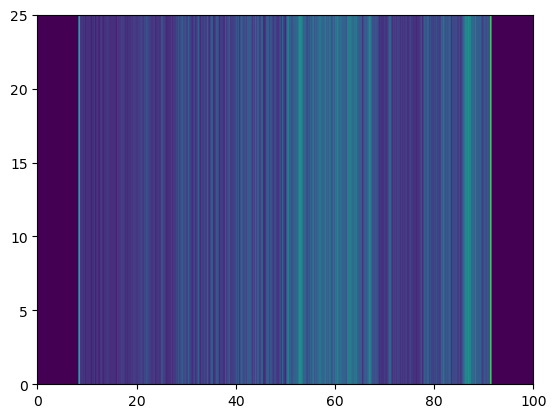

In [12]:
plt.imshow(np.log(np.abs(W.T)+1e-3), aspect='auto', extent=[0, duration, 0, 1/(2*T)], cmap='viridis', origin='lower')

In [9]:
print(W.shape)

(6024, 1)


327.44182140965154 1045.85780745
Reconstruction error: 589.5189320763621


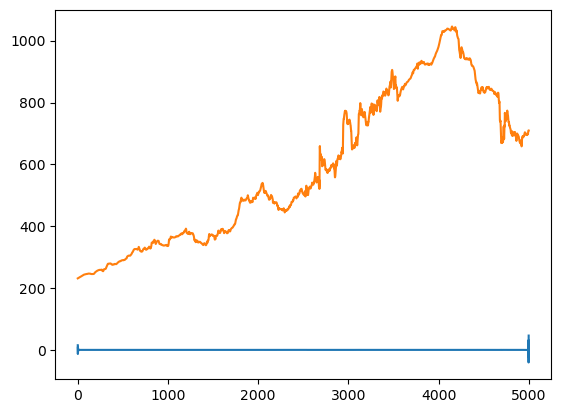

In [10]:
plt.plot(np.sqrt(1/50)*data_rec)
plt.plot(data)
print(np.max(data_rec), np.max(data))
print("Reconstruction error:",
       np.sqrt(np.mean(data[100:-100] - data_rec[100:-100])**2))

Reconstruction error: 3.6036175722099264


c:\Users\aphoffm2\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\aphoffm2\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


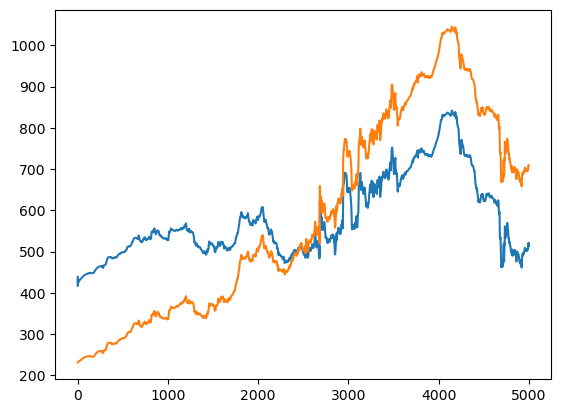

In [16]:
from wavelets import WaveletAnalysis as WA
w1 = WA(data, dt=T, dj=1/8, frequency=True, unbias=False, mask_coi = True)
wn1 = w1.wavelet_transform.real
W_n = wn1 
Y_00 = w1.wavelet.time(0)
s = w1.scales
r_sum = np.sum(W_n.real.T / s ** .5, axis=-1).T
amb_mf = r_sum * (1/8 * T ** .5 / (w1.C_d * Y_00))
amb_mf += w1.data.mean(axis=w1.axis, keepdims=True)
plt.plot(amb_mf)
plt.plot(swarm[0])
print("Reconstruction error:", np.sqrt(np.mean(data[100:-100] - amb_mf[100:-100].real)**2))

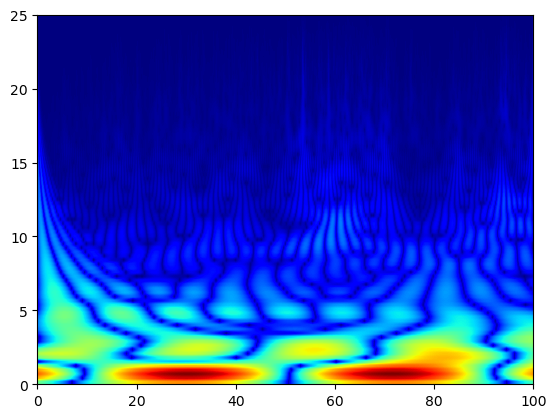

In [18]:
plt.imshow(np.abs(wn1)**.5, aspect='auto', extent=[0, duration, 0, 1/(2*T)], cmap='jet')